In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [70]:
from sklearn.svm import SVC

In [71]:
from  sklearn         import  metrics
from  sklearn.metrics import  accuracy_score
from  sklearn.metrics import  precision_score
from  sklearn.metrics import  recall_score
from  sklearn.metrics import  f1_score
from  sklearn.metrics import  confusion_matrix
from  sklearn.metrics import  ConfusionMatrixDisplay
from  sklearn.metrics import  classification_report

from  sklearn.model_selection import  cross_val_score
from  sklearn.model_selection import  train_test_split
from  sklearn.model_selection import  GridSearchCV

In [72]:
dataset = pd.read_csv('file/WeightHeight.csv') 
df = pd.DataFrame(dataset) 
df

,W,H,Normal
0,88,173,yes
1,95,180,yes
2,100,191,yes
3,70,177,yes
4,50,160,yes
5,60,150,yes
6,75,165,yes
7,130,170,no
8,70,192,no
9,60,190,no


In [73]:
df.shape

(13, 3)

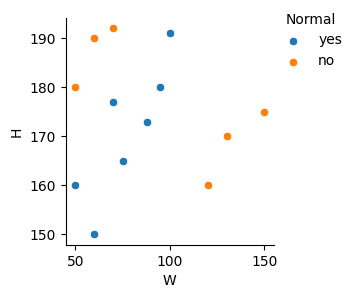

In [74]:
fg = sns.FacetGrid(df, hue='Normal')
fg.map(sns.scatterplot, 'W', 'H');
fg.add_legend(loc=1)

In [75]:
X = df.drop(['Normal'], axis=1)  
X

,W,H
0,88,173
1,95,180
2,100,191
3,70,177
4,50,160
5,60,150
6,75,165
7,130,170
8,70,192
9,60,190


In [76]:
y = df['Normal'] 
y

0     yes
1     yes
2     yes
3     yes
4     yes
5     yes
6     yes
7      no
8      no
9      no
10     no
11     no
12     no
Name: Normal, dtype: object

In [77]:
# ml

In [135]:
clf = SVC(kernel='poly')     

In [136]:
clf.fit(X, y)

SVC(kernel='poly')

In [137]:
clf.predict([[90,180]])

array(['yes'], dtype=object)

In [138]:
X_test = [[50,175],[60,190],[125,160],[120,150],[120,190],[98,175],[78,170]]
y_test = ['no','no','no','no','yes','yes','yes']

y_pred = clf.predict(X_test)
y_pred

array(['no', 'no', 'no', 'no', 'no', 'yes', 'yes'], dtype=object)

In [139]:
y_test == y_pred

array([ True,  True,  True,  True, False,  True,  True])

In [140]:
confusion_matrix(y_test, y_pred)

array([[4, 0],
       [1, 2]])

In [141]:
arr = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = arr.reshape(-1)  
tn, fp, fn, tp

(np.int64(4), np.int64(0), np.int64(1), np.int64(2))

In [142]:
print(classification_report(y_test, y_pred))  

              precision    recall  f1-score   support

          no       0.80      1.00      0.89         4
         yes       1.00      0.67      0.80         3

    accuracy                           0.86         7
   macro avg       0.90      0.83      0.84         7
weighted avg       0.89      0.86      0.85         7



In [143]:
metrics.precision_recall_fscore_support(y_test, y_pred) 

(array([0.8, 1. ]),
 array([1.        , 0.66666667]),
 array([0.88888889, 0.8       ]),
 array([4, 3]))

In [144]:
metrics.precision_recall_fscore_support(y_test, y_pred, average='weighted') 

(0.8857142857142858, 0.8571428571428571, 0.8507936507936508, None)

In [88]:
# train_test_split

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)   #, random_state=27

In [113]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9, 2), (4, 2), (9,), (4,))

In [114]:
X_test

,W,H
0,88,173
9,60,190
5,60,150
11,150,175


In [115]:
clf = SVC(kernel='poly')     
clf.fit(X_train,y_train)

SVC(kernel='poly')

In [116]:
y_pred = clf.predict(X_test)

In [117]:
arr = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = arr.reshape(-1)  
tn, fp, fn, tp

(np.int64(2), np.int64(0), np.int64(0), np.int64(2))

In [120]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       1.00      1.00      1.00         2
         yes       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [96]:
# cross validation

In [134]:
clf = SVC(kernel='poly')     
scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
scores

array([0.5, 0.5, 0.5, 0. , 1. ])

In [98]:
scores.mean()

np.float64(0.8)

In [99]:
#

In [100]:
p = {
    'kernel' : ['linear', 'poly', 'rbf'],
    'gamma'  : ['scale', 'auto'],
    'degree' : [1, 2, 3, 4, 5]
}

g = GridSearchCV(clf, p, n_jobs= -1, cv=5)
g.fit(X_train, y_train)
print(g.best_params_) 

{'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}


In [101]:
#

In [102]:
models = []
models.append(('Poly'  , SVC(kernel='poly', degree= 2, gamma= 'auto')))
models.append(('Linear', SVC(kernel='linear')))
models.append(('RBF'   , SVC(kernel='rbf')))


results = []
names = []

for name, model in models:
	cvr = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
	results.append(cvr)
	names.append(name)
	print('%s : %0.2f' % (name, cvr.mean()))

Poly : 0.70
Linear : 0.60
RBF : 0.40
